In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_fscore_support
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import copy

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Edge AI/device2_air_quality_2024-09-25_to_2025-04-07.csv")

In [3]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

drop_cols = [col for col in ["deviceId", "payload_id"] if col in df.columns]
df = df.drop(columns=drop_cols)

print("\nInitial Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate timestamps:", df["Timestamp"].duplicated().sum())

df = df.drop_duplicates(subset="Timestamp").reset_index(drop=True)


Initial Shape: (52259, 8)

Missing values:
Timestamp          0
air_temperature    0
humidity           0
CO2                0
pm1                0
pm10               0
pm2_5              0
air_pressure       0
dtype: int64

Duplicate timestamps: 0


In [4]:
df["time_diff_min"] = df["Timestamp"].diff().dt.total_seconds() / 60

print("\nTime difference statistics (minutes):")
print(df["time_diff_min"].describe())
print("\nLarge gaps (>10 min):", (df["time_diff_min"] > 10).sum())


Time difference statistics (minutes):
count    52258.000000
mean         5.346933
std         19.476770
min          5.000000
25%          5.000000
50%          5.000000
75%          5.000000
max       2590.000000
Name: time_diff_min, dtype: float64

Large gaps (>10 min): 216


In [5]:
required_cols = ["Timestamp", "air_temperature", "humidity", "CO2", "pm2_5"]
df = df[required_cols].copy()

In [6]:
sensor_cols = ["air_temperature", "humidity", "CO2", "pm2_5"]
df[sensor_cols] = df[sensor_cols].ffill().bfill()

In [7]:
clip_ranges = {
    "CO2": (300, 5000),
    "pm2_5": (5, 500),
    "air_temperature": (18, 40),
    "humidity": (25, 95)
}

for col, (low, high) in clip_ranges.items():
    df[col] = df[col].clip(lower=low, upper=high)

print("\nBasic statistics after clipping:")
print(df[sensor_cols].describe())


Basic statistics after clipping:
       air_temperature      humidity           CO2         pm2_5
count     52259.000000  52259.000000  52259.000000  52259.000000
mean         27.544497     57.515496    735.736868     82.275977
std           4.078550     14.276959    549.831739     53.690039
min          19.280000     26.910000    300.000000      5.000000
25%          24.280000     44.530000    432.000000     44.600000
50%          27.360000     59.780000    468.000000     64.400000
75%          30.460000     69.130000    776.000000    108.700000
max          37.960000     85.950000   4347.000000    500.000000


In [8]:
future_minutes = 25
tolerance_minutes = 5

target_times = df["Timestamp"] + pd.Timedelta(minutes=future_minutes)

future_df = df[["Timestamp", "CO2", "pm2_5"]].copy()
future_df = future_df.rename(columns={
    "Timestamp": "future_timestamp_actual",
    "CO2": "future_CO2",
    "pm2_5": "future_pm2_5"
})

temp = pd.DataFrame({"target_time": target_times})

matched = pd.merge_asof(
    temp.sort_values("target_time"),
    future_df.sort_values("future_timestamp_actual"),
    left_on="target_time",
    right_on="future_timestamp_actual",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=tolerance_minutes)
)

df["future_CO2"] = matched["future_CO2"].values
df["future_pm2_5"] = matched["future_pm2_5"].values

df["will_be_bad"] = np.where(
    df["future_CO2"].notna() & df["future_pm2_5"].notna(),
    ((df["future_CO2"] > 1400) | (df["future_pm2_5"] > 65)).astype(int),
    np.nan
)

print("\nTarget distribution before dropping NaNs:")
print(df["will_be_bad"].value_counts(dropna=False))

df = df.dropna(subset=["will_be_bad"]).reset_index(drop=True)
df["will_be_bad"] = df["will_be_bad"].astype(int)

print("\nWarning rate: {:.2f}%".format(df["will_be_bad"].mean() * 100))


Target distribution before dropping NaNs:
will_be_bad
1.0    28616
0.0    23424
NaN      219
Name: count, dtype: int64

Warning rate: 54.99%


In [9]:
df["temp_pm_interaction"] = df["air_temperature"] * df["pm2_5"]
df["co2_per_humidity"] = df["CO2"] / (df["humidity"] + 1)

In [10]:
feature_cols = [
    "air_temperature",
    "humidity",
    "CO2",
    "pm2_5",
    "temp_pm_interaction",
    "co2_per_humidity"
]

X = df[feature_cols].copy()
y = df["will_be_bad"].copy()

print("\nFinal dataset shape:", X.shape)
print("\nFinal target distribution:")
print(y.value_counts(normalize=True))


Final dataset shape: (52040, 6)

Final target distribution:
will_be_bad
1    0.549885
0    0.450115
Name: proportion, dtype: float64


In [11]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_raw = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_val_raw = X.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()

X_test_raw = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()

print("\nSplit sizes:")
print("Train:", X_train_raw.shape, y_train.shape)
print("Val  :", X_val_raw.shape, y_val.shape)
print("Test :", X_test_raw.shape, y_test.shape)

print("\nClass balance:")
print("Train warning rate:", y_train.mean())
print("Val warning rate  :", y_val.mean())
print("Test warning rate :", y_test.mean())


Split sizes:
Train: (36428, 6) (36428,)
Val  : (7806, 6) (7806,)
Test : (7806, 6) (7806,)

Class balance:
Train warning rate: 0.7153563193148128
Val warning rate  : 0.16461696131181142
Test warning rate : 0.16295157571099156


In [12]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

In [13]:
sequence_length = 6

def create_sequences(X_array, y_array, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X_array)):
        X_seq.append(X_array[i-seq_len:i])
        y_seq.append(y_array.iloc[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, sequence_length)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, sequence_length)

print("\nSequence shapes:")
print("X_train_seq:", X_train_seq.shape, "y_train_seq:", y_train_seq.shape)
print("X_val_seq  :", X_val_seq.shape, "y_val_seq  :", y_val_seq.shape)
print("X_test_seq :", X_test_seq.shape, "y_test_seq :", y_test_seq.shape)


Sequence shapes:
X_train_seq: (36422, 6, 6) y_train_seq: (36422,)
X_val_seq  : (7800, 6, 6) y_val_seq  : (7800,)
X_test_seq : (7800, 6, 6) y_test_seq : (7800,)


In [14]:
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_seq, dtype=torch.long).to(device)

X_val_t = torch.tensor(X_val_seq, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val_seq, dtype=torch.long).to(device)

X_test_t = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_seq, dtype=torch.long).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [15]:
class IAQLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=48, num_layers=2, dropout=0.25):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc1 = nn.Linear(hidden_size, 24)
        self.fc2 = nn.Linear(24, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = IAQLSTM(input_size=X_train_seq.shape[2]).to(device)

In [16]:
class_counts = np.bincount(y_train_seq)
total_samples = len(y_train_seq)

class_weights = torch.tensor(
    [
        total_samples / (2 * class_counts[0]),
        total_samples / (2 * class_counts[1])
    ],
    dtype=torch.float32
).to(device)

print("\nClass counts in training sequences:", class_counts)
print("Class weights:", class_weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)


Class counts in training sequences: [10369 26053]
Class weights: [1.7562928 0.6989982]


In [17]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
patience = 8
counter = 0
num_epochs = 60

print("\nTraining started...\n")

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)


Training started...

Epoch  5/60 | Train Loss: 0.1421 | Val Loss: 0.1683
Epoch 10/60 | Train Loss: 0.1312 | Val Loss: 0.1586
Epoch 15/60 | Train Loss: 0.1222 | Val Loss: 0.1590
Epoch 20/60 | Train Loss: 0.1181 | Val Loss: 0.1554
Epoch 25/60 | Train Loss: 0.1159 | Val Loss: 0.1472
Epoch 30/60 | Train Loss: 0.1137 | Val Loss: 0.1438
Epoch 35/60 | Train Loss: 0.1107 | Val Loss: 0.1337
Epoch 40/60 | Train Loss: 0.1090 | Val Loss: 0.1278
Epoch 45/60 | Train Loss: 0.1079 | Val Loss: 0.1259
Epoch 50/60 | Train Loss: 0.1071 | Val Loss: 0.1166
Epoch 55/60 | Train Loss: 0.1046 | Val Loss: 0.1132
Epoch 60/60 | Train Loss: 0.1041 | Val Loss: 0.1089


<All keys matched successfully>

In [18]:
model.eval()
with torch.no_grad():
    val_outputs = model(X_val_t)
    val_prob = torch.softmax(val_outputs, dim=1)[:, 1].cpu().numpy()

threshold_candidates = np.arange(0.10, 0.91, 0.05)
results = []

for th in threshold_candidates:
    y_pred_val = (val_prob > th).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val_seq,
        y_pred_val,
        average="binary",
        zero_division=0
    )
    results.append([th, precision, recall, f1])

threshold_df = pd.DataFrame(
    results, columns=["threshold", "precision", "recall", "f1"]
)

best_row = threshold_df.iloc[threshold_df["f1"].idxmax()]
best_threshold = float(best_row["threshold"])

print("\nThreshold tuning results on validation set:")
print(threshold_df)

print("\nBest threshold based on validation F1:")
print(best_row)
print(f"\nSelected Threshold: {best_threshold:.2f}")


Threshold tuning results on validation set:
    threshold  precision    recall        f1
0        0.10   0.778615  0.888194  0.829803
1        0.15   0.837733  0.843628  0.840670
2        0.20   0.872103  0.794371  0.831424
3        0.25   0.899446  0.762314  0.825222
4        0.30   0.918208  0.737295  0.817866
5        0.35   0.932990  0.707584  0.804802
6        0.40   0.941748  0.682565  0.791478
7        0.45   0.955069  0.648163  0.772240
8        0.50   0.962195  0.616888  0.751787
9        0.55   0.971795  0.592651  0.736280
10       0.60   0.983673  0.565285  0.717974
11       0.65   0.985856  0.544957  0.701913
12       0.70   0.986686  0.521501  0.682353
13       0.75   0.990640  0.496482  0.661458
14       0.80   0.990212  0.474590  0.641649
15       0.85   0.994774  0.446443  0.616298
16       0.90   0.996212  0.411259  0.582180

Best threshold based on validation F1:
threshold    0.150000
precision    0.837733
recall       0.843628
f1           0.840670
Name: 1, dtype: f

In [19]:
with torch.no_grad():
    test_outputs = model(X_test_t)
    y_prob = torch.softmax(test_outputs, dim=1)[:, 1].cpu().numpy()

y_pred = (y_prob > best_threshold).astype(int)

print("\nFinal Test Results")
print(f"Accuracy : {accuracy_score(y_test_seq, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_seq, y_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred, target_names=["Safe", "Warning"]))


Final Test Results
Accuracy : 0.9169
ROC-AUC  : 0.9645

Classification Report:
              precision    recall  f1-score   support

        Safe       0.94      0.96      0.95      6528
     Warning       0.78      0.68      0.73      1272

    accuracy                           0.92      7800
   macro avg       0.86      0.82      0.84      7800
weighted avg       0.91      0.92      0.91      7800



In [20]:
baseline_auc = roc_auc_score(y_test_seq, y_prob)
importances = []

for i, feature in enumerate(feature_cols):
    scores = []

    for _ in range(5):
        X_permuted = X_test_t.clone()
        perm_idx = torch.randperm(X_permuted.shape[0])
        X_permuted[:, :, i] = X_permuted[perm_idx, :, i]

        with torch.no_grad():
            outputs_perm = model(X_permuted)
            prob_perm = torch.softmax(outputs_perm, dim=1)[:, 1].cpu().numpy()

        perm_auc = roc_auc_score(y_test_seq, prob_perm)
        scores.append(perm_auc)

    importance = baseline_auc - np.mean(scores)
    importances.append(importance)

perm_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print("\nFinal Feature Importance:")
print(perm_importance)


Final Feature Importance:
CO2                    0.153738
temp_pm_interaction    0.061226
pm2_5                  0.040058
co2_per_humidity       0.033980
air_temperature        0.017212
humidity               0.001658
dtype: float64


In [21]:
cm = confusion_matrix(y_test_seq, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[6288  240]
 [ 408  864]]


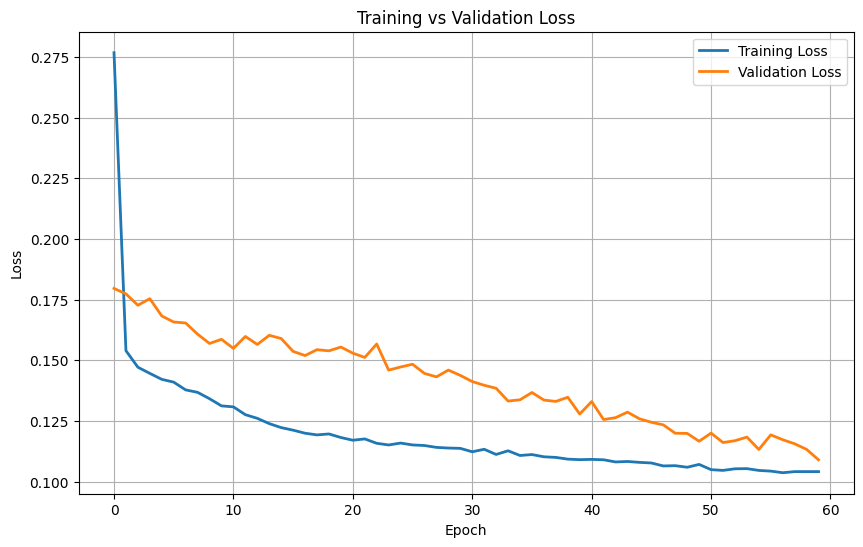

In [22]:
# Training vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

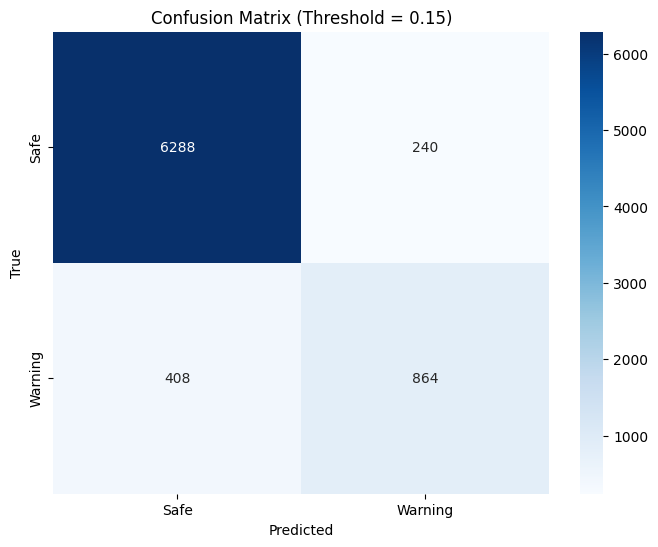

In [23]:
# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Safe", "Warning"],
    yticklabels=["Safe", "Warning"]
)
plt.title(f"Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

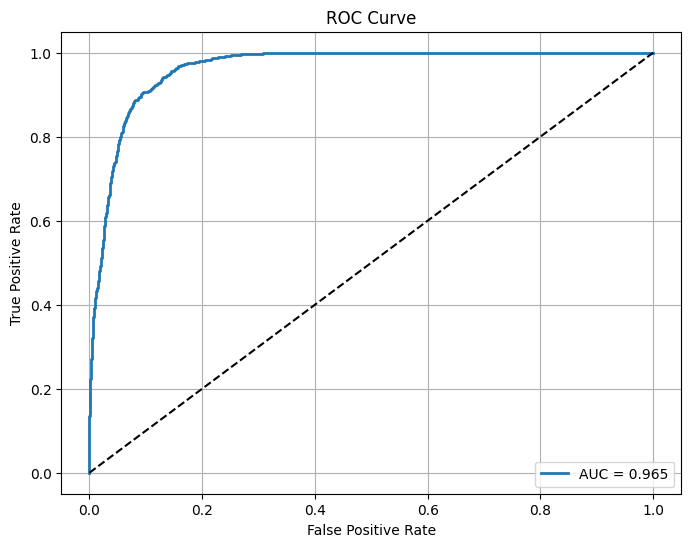

In [24]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test_seq, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_seq, y_prob):.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

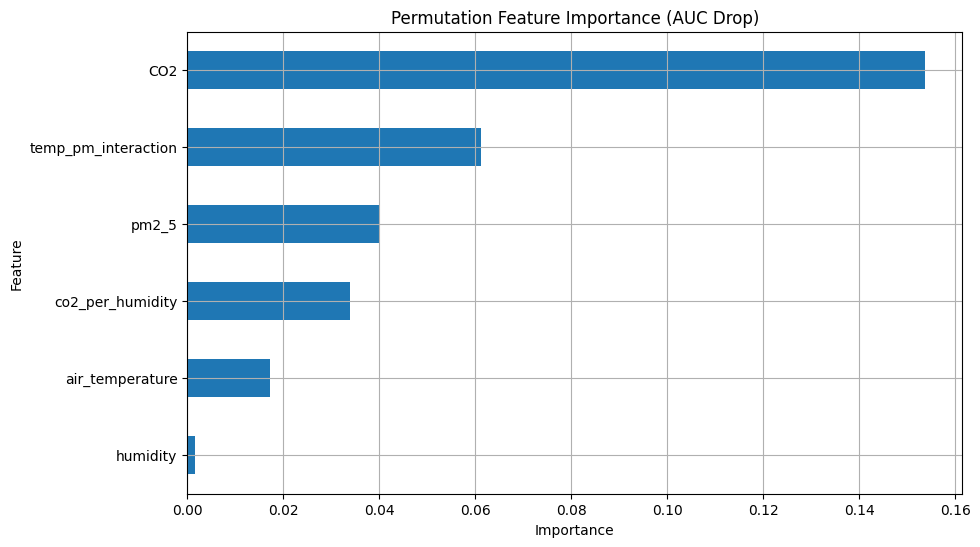

In [25]:
# Feature importance
plt.figure(figsize=(10, 6))
perm_importance.sort_values().plot(kind="barh")
plt.title("Permutation Feature Importance (AUC Drop)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

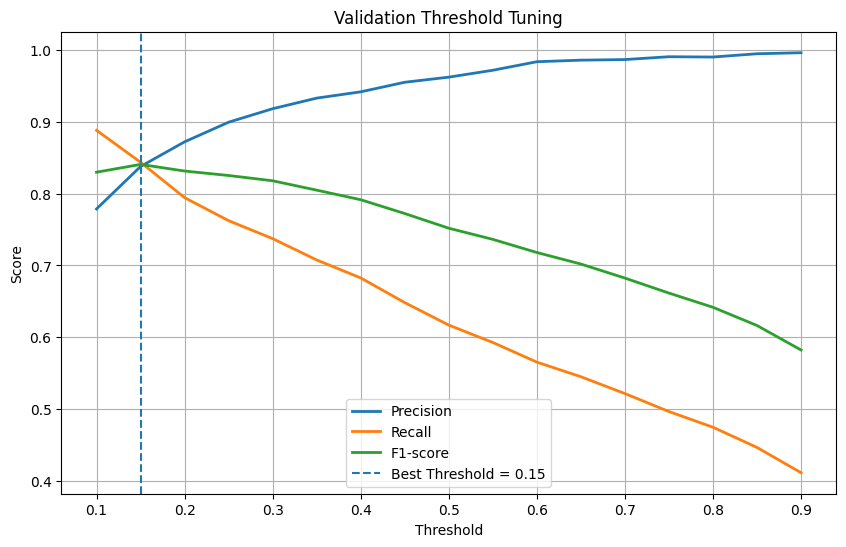

In [26]:
# Threshold tuning plot
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2)
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", linewidth=2)
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-score", linewidth=2)
plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold:.2f}")
plt.title("Validation Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
import os
import json
import joblib
from pathlib import Path

# =========================
# 23. SAVE FOR EDGE DEPLOYMENT
# =========================
save_dir = Path("/content/drive/MyDrive/Edge AI/iaq_edge_export")
save_dir.mkdir(parents=True, exist_ok=True)

# Put model on CPU before export for widest compatibility
model_cpu = copy.deepcopy(model).to("cpu")
model_cpu.eval()

# Save TorchScript model
example_input = torch.randn(1, sequence_length, len(feature_cols), dtype=torch.float32)
traced_model = torch.jit.trace(model_cpu, example_input)
torchscript_path = save_dir / "iaq_predictor_lstm.ts"
traced_model.save(str(torchscript_path))

# Save scaler
scaler_path = save_dir / "robust_scaler.joblib"
joblib.dump(scaler, scaler_path)

# Save metadata needed by the edge device
metadata = {
    "model_type": "IAQ 25-minute warning predictor",
    "prediction_type": "binary_risk_of_bad_air_in_next_25_minutes",
    "bad_air_definition": {
        "future_CO2_gt": 1400,
        "future_pm2_5_gt": 65
    },
    "future_minutes": future_minutes,
    "expected_sampling_interval_minutes": 5,
    "sequence_length": sequence_length,
    "feature_cols": feature_cols,
    "threshold": float(best_threshold),
    "sensor_inputs_required": [
        "air_temperature",
        "humidity",
        "CO2",
        "pm2_5"
    ],
    "derived_features_formulae": {
        "temp_pm_interaction": "air_temperature * pm2_5",
        "co2_per_humidity": "CO2 / (humidity + 1)"
    },
    "scaler_type": "RobustScaler",
    "model_input_shape": [1, sequence_length, len(feature_cols)],
    "model_output": {
        "class_0": "Safe",
        "class_1": "Warning"
    }
}

metadata_path = save_dir / "metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

# Optional: save scaler arrays in a lightweight NPZ too
np.savez(
    save_dir / "scaler_arrays.npz",
    center_=scaler.center_,
    scale_=scaler.scale_
)

print("\nSaved edge deployment files:")
print(f"TorchScript model : {torchscript_path}")
print(f"Scaler (joblib)   : {scaler_path}")
print(f"Scaler arrays     : {save_dir / 'scaler_arrays.npz'}")
print(f"Metadata          : {metadata_path}")


Saved edge deployment files:
TorchScript model : /content/drive/MyDrive/Edge AI/iaq_edge_export/iaq_predictor_lstm.ts
Scaler (joblib)   : /content/drive/MyDrive/Edge AI/iaq_edge_export/robust_scaler.joblib
Scaler arrays     : /content/drive/MyDrive/Edge AI/iaq_edge_export/scaler_arrays.npz
Metadata          : /content/drive/MyDrive/Edge AI/iaq_edge_export/metadata.json
